In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [29]:
# Cấu hình font chữ
plt.rcParams['font.family'] = 'Georgia'

In [30]:
# Đọc dữ liệu
df = pd.read_csv("../data/processed/Cleaned_Global_Cybersecurity_Threats_2015-2024.csv")

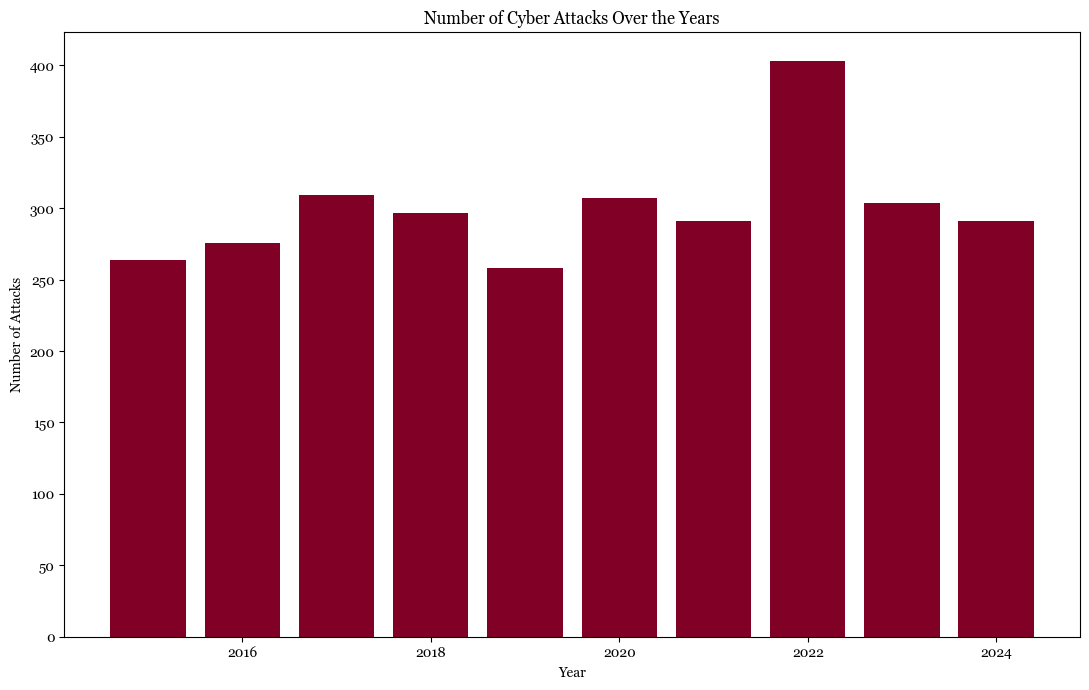

In [31]:
# --- Biểu đồ số lượng tấn công theo năm ---
attacks_per_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(11, 7))
plt.bar(attacks_per_year.index, attacks_per_year.values, color='#800026')
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.title("Number of Cyber Attacks Over the Years")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
# --- Thống kê phần trăm các loại hình tấn công ---
attack_counts = df['Attack Type'].value_counts(normalize=True) * 100
attack_counts = attack_counts.round(1)

print("Tỷ lệ phần trăm các loại hình tấn công:")
print(attack_counts)

Tỷ lệ phần trăm các loại hình tấn công:
Attack Type
Phishing             20.0
Ddos                 17.0
Sql Injection        16.3
Ransomware           16.0
Malware              15.9
Man-In-The-Middle    14.8
Name: proportion, dtype: float64


In [33]:
# --- Bản đồ các quốc gia bị tấn công nhiều nhất ---
country_attacks = df['Country'].str.strip().value_counts().reset_index()
country_attacks.columns = ['Country', 'Attack count']

fig = px.choropleth(
    country_attacks,
    locations='Country',
    locationmode='country names',
    color='Attack count',
    color_continuous_scale='ylorrd',
    title='Map of Most Attacked Countries'
)
fig.update_layout(margin={"l": 20, "r": 20, "t": 40, "b": 20})
fig.show()